In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
data = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only the two useful columns
data = data.iloc[:, :2]
data.columns = ["label", "message"]

print("Dataset shape:", data.shape)
data.head()


Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("Class distribution:")
print(data["label"].value_counts())

print("\nMissing values:")
print(data.isnull().sum())


Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


In [4]:
# Convert labels: ham = 0, spam = 1
data["label"] = data["label"].map({"ham": 0, "spam": 1})

X = data["message"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 4457
Testing samples: 1115


In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF matrix shape:", X_train_tfidf.shape)
print("Testing TF-IDF matrix shape:", X_test_tfidf.shape)


Training TF-IDF matrix shape: (4457, 7440)
Testing TF-IDF matrix shape: (1115, 7440)


In [6]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")


Model training completed successfully!


In [7]:
y_pred = model.predict(X_test_tfidf)

print("First 10 predictions:", y_pred[:10])


First 10 predictions: [0 0 0 1 0 0 0 0 0 0]


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


Accuracy: 0.9686

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



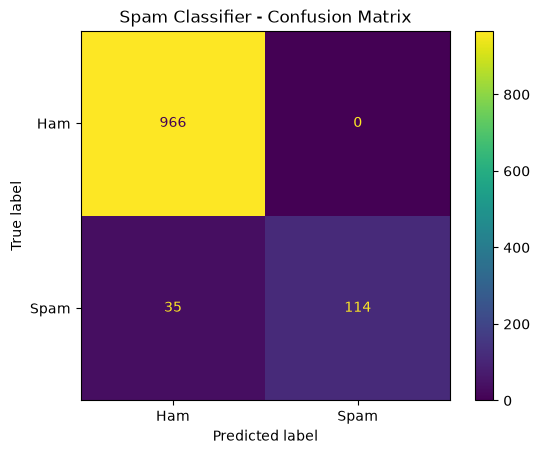

In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)
disp.plot()
plt.title("Spam Classifier - Confusion Matrix")
plt.show()


In [10]:
messages = [
    "Congratulations! You have won a free lottery ticket!",
    "Hey, are we meeting for class tomorrow?",
    "URGENT! You have won $1000. Click the link now!",
    "Can you send me the notes?"
]

messages_tfidf = vectorizer.transform(messages)
predictions = model.predict(messages_tfidf)

for message, prediction in zip(messages, predictions):
    result = "SPAM" if prediction == 1 else "NOT SPAM"
    print(f"Message: {message}")
    print(f"Prediction: {result}\n")


Message: Congratulations! You have won a free lottery ticket!
Prediction: NOT SPAM

Message: Hey, are we meeting for class tomorrow?
Prediction: NOT SPAM

Message: URGENT! You have won $1000. Click the link now!
Prediction: SPAM

Message: Can you send me the notes?
Prediction: NOT SPAM



## Conclusion

The project demonstrates a complete text-classification pipeline: SMS text is transformed into TF-IDF features and classified using Multinomial Naive Bayes. The model is evaluated using accuracy, a classification report and a confusion matrix.